**Steps:**

1) Combine and preprocess datasets

2) Train model

3) Evaluate trained model

4) Multiple pruning methods with fine-tuning

5) Evaluate all pruning results

6) Save final model

7) Port to Jetson and run

# Imports and Connection

In [1]:
# IMPORTS #
import numpy as np
from google.colab import drive
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedShuffleSplit
import cv2
import pandas as pd
import glob
import os
from typing import Iterable
import time
import datetime
from collections import defaultdict, deque
import math
import timm
from timm.utils import accuracy
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models
import torch.distributed as dist
import torch.nn.utils.prune as prune
import torch.quantization
from torch.quantization import get_default_qconfig, prepare, convert, QuantStub, DeQuantStub, fuse_modules
from tqdm import tqdm
from torchsummary import summary

In [2]:
# CONNECT TO GOOGLE DRIVE #
drive.mount('/content/drive')

Mounted at /content/drive


# Function Library

### Image Processing

In [3]:
#Image preprocessing function
def preprocess_images(image_path, output_path, copies):
    'Converts the image at the input path, and can save it in a different folder (i.e. the processed data folder) as a jpg file.'
    os.makedirs(output_path, exist_ok=True)

    image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tiff", "*.webp"] #List of accepted file formats, so long as cv can do it we can add it here
    images = []
    for ext in image_extensions: #Find the all images at the target path for each extension
      images.extend(glob.glob(os.path.join(image_path, ext)))

    count = 0
    for img_file in images:
      img = cv2.imread(img_file, cv2.IMREAD_GRAYSCALE)  #Convert to grayscale
      img = cv2.resize(img, (256, 256))  #Resize
      img = img / 255.0  #Normalize
      save_count = 0
      while save_count < copies:
        count += 1
        save_count += 1
        save_file = os.path.join(output_path, f"{count:08d}.jpg") #Save it as a renamed jpg
        cv2.imwrite(save_file, (img * 255).astype(np.uint8))  #Save processed image
      if count % 100 == 0:
        print(f"Processed {image_path} {count}")


## Setup and Utilities

In [4]:
#Function to control what layers of a model are trainable
def freeze_layers(model, n):
    #Freeze all model parameters first
    for param in model.parameters():
      param.requires_grad = False

    #Unfreeze the last n layers
    layers = list(model.children()) #Load the layers from the model
    unfrozen_layers = layers[-n:]
    for layer in unfrozen_layers:
      for param in layer.parameters():
        param.requires_grad = True

In [5]:
#Sets all the different libraries that we use to the same seed for reproduction
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    #Torch needs a if statement because its a special boy
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [6]:
#Main model training function, used for all the different methods
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    #Best running accuracy for the training
    best_val_accuracy = 0.0

    #Loop over the epochs
    for epoch in range(num_epochs):
      model.train()  # Set the model to training mode

      #Epoch parameters
      running_loss = 0.0
      correct_train = 0
      total_train = 0

      # Training loop #
      for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} - Training'):
        #Load the dataset onto wherever the model is stored (cuda device from parameters)
        images, labels = images.to(device), labels.to(device)

        #Zero the gradients to avoid tracking useless information (https://pytorch.org/tutorials/recipes/recipes/zeroing_out_gradients.html#:~:text=Zero%20the%20gradients%20while%20training%20the%20network,-This%20is%20when&text=Notice%20that%20for%20each%20entity,we%20train%20our%20neural%20network.&text=You%20can%20also%20use%20model,zero_grad()%20.)
        optimizer.zero_grad()

        #Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        #Backward pass + optimize
        loss.backward()
        optimizer.step()
        loss.detach() #Save memory by detaching the loss

        #Get loss and accuracy
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

      #Calculate the training loss and accuracy for the epoch
      train_loss = running_loss / len(train_loader)
      train_accuracy = correct_train / total_train * 100

      # Validation loop #
      model.eval()  # Set the model to evaluation mode
      correct_val = 0
      total_val = 0


      #Calculate the accuracy on the validation data
      with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            #Forward pass - no backwards pass needed
            outputs = model(images)

            #Calculate accuracy total
            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)

      #Calculate the validation accuracy as %
      val_accuracy = correct_val / total_val * 100

      #Print the statistics for the current epoch (helps us see where issues are occuring)
      print(f"Epoch [{epoch+1}/{num_epochs}], "
            f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, "
            f"Val Accuracy: {val_accuracy:.2f}%")

      #Save the model if it has the best validation accuracy so far. If not, the best will be sent though the train/test loop again
      if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), 'best_mobilenetv2_model.pth')
        print(f"Model saved with validation accuracy of {best_val_accuracy:.2f}%")

In [7]:
#Metric function - accuracy
def evaluate_accuracy(model, test_loader):
    model.eval()  #Set the model to evaluation mode
    correct_val = 0
    total_val = 0

    #Calculate the accuracy on the validation data - copied from the train function
    with torch.no_grad():
      for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        #Forward pass - no backwards pass needed
        outputs = model(images)

        #Calculate accuracy total
        _, predicted = torch.max(outputs, 1)
        correct_val += (predicted == labels).sum().item()
        total_val += labels.size(0)

    #Calculate the validation accuracy as %
    val_accuracy = correct_val / total_val * 100

    return val_accuracy

In [8]:
#Metric function - quant accuracy (has to move things to the CPU, otherwise same as above)
def evaluate_quant_accuracy(model, test_loader):
    model.eval()  #Set the model to evaluation mode
    correct_val = 0
    total_val = 0

    #Calculate the accuracy on the validation data - copied from the train function
    with torch.no_grad():
      for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        images = images.to('cpu')
        labels = labels.to('cpu')

        #Forward pass - no backwards pass needed
        outputs = model(images)

        #Calculate accuracy total
        _, predicted = torch.max(outputs, 1)
        correct_val += (predicted == labels).sum().item()
        total_val += labels.size(0)

    #Calculate the validation accuracy as %
    val_accuracy = correct_val / total_val * 100

    return val_accuracy

In [9]:
def evaluate_model_time(model):
    #Give it a set of random inputs and see how long it takes to classify it
    runs = 10
    total_time = 0.0

    device = next(model.parameters()).device

    for _ in range(runs):
      #Generate a random input, it doesn't matter that it doesn't look like anything it just needs to pass though to check time
      fake_input = torch.randn(1, 3, 224, 224)
      fake_input = fake_input.to(device)
      start_time = time.time()
      with torch.no_grad():
          _ = model(fake_input)
      total_time += time.time() - start_time

    avg_inference_time = total_time / runs
    return avg_inference_time

In [10]:
#A count of the total parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

In [11]:
#From stack overflow - jpeg729 (modified to count non-zeros instead of zeros)
def count_nonzero_weights(model):
    non_zeros = 0
    for param in model.parameters():
      non_zeros += torch.count_nonzero(param).item()
    return non_zeros

In [12]:
#Pruning function specific to threshold pruning
def threshold_prune_model(model, threshold):
    for module in model.modules():
      if isinstance(module, (nn.Linear, nn.Conv2d)):
        #Create the puning mask
        weight = module.weight.data
        mask = (weight.abs() >= threshold) #If the weight is less or equal to the threshold, it is set to 0

        #Apply pruning using the mask
        prune.custom_from_mask(module, name="weight", mask=mask)

        #Remove the reparameterization so the weights are truly pruned
        prune.remove(module, "weight")
    return model

In [13]:
#Freeze the pruned weights for the threshold pruning (Assisted by Chat GPT for this function)
def apply_gradient_mask(model, threshold):
    for module in model.modules():
      if isinstance(module, (nn.Linear, nn.Conv2d)):
        weight = module.weight.data
        mask = (weight.abs() >= threshold).float()

        def backward_hook(grad, mask=mask):
          return grad * mask
        #Register the hook
        module.weight.register_hook(backward_hook)

In [14]:
# Register hook to freeze pruned weights
def freeze_pruned_grads(module):
    if module in mask_dict:
      mask = mask_dict[module] #Loads the mask_dict at the correct spot (declared in the unstructured cells)
      def hook(grad):
        return grad * mask  #Zero out the gradients of pruned weights
      #Register the hook
      module.weight.register_hook(hook)

# Important Variables

In [15]:
#Main Dataset Path
main_path = '/content/drive/My Drive/ENDG511GroupProject/'
unprocessed_path = main_path + 'Datasets/complete_dataset_unprocessed/'
processed_path = main_path + 'Datasets/complete_dataset_processed/'
image_classes = ['plane', 'ship', 'engineering_platform', 'pipeline_cable', 'seabed_surface', 'underwater_residual_mound']


# Image preparation (Preprocessing)

In [ ]:
 #Do not run unless you change the dataset, takes time + compute units for no reason

copies = 4 #How many copies to make to account for the random transformations
for i in range(len(image_classes)):
  preprocess_images(unprocessed_path + image_classes[i], processed_path + image_classes[i], copies)
  print(f"Completed Processing of: {unprocessed_path + image_classes[i]}")

Processed /content/drive/My Drive/ENDG511GroupProject/Datasets/complete_dataset_unprocessed/plane 100
Processed /content/drive/My Drive/ENDG511GroupProject/Datasets/complete_dataset_unprocessed/plane 200
Processed /content/drive/My Drive/ENDG511GroupProject/Datasets/complete_dataset_unprocessed/plane 300
Processed /content/drive/My Drive/ENDG511GroupProject/Datasets/complete_dataset_unprocessed/plane 400
Completed Processing of: /content/drive/My Drive/ENDG511GroupProject/Datasets/complete_dataset_unprocessed/plane
Processed /content/drive/My Drive/ENDG511GroupProject/Datasets/complete_dataset_unprocessed/ship 100
Processed /content/drive/My Drive/ENDG511GroupProject/Datasets/complete_dataset_unprocessed/ship 200
Processed /content/drive/My Drive/ENDG511GroupProject/Datasets/complete_dataset_unprocessed/ship 300
Processed /content/drive/My Drive/ENDG511GroupProject/Datasets/complete_dataset_unprocessed/ship 400
Processed /content/drive/My Drive/ENDG511GroupProject/Datasets/complete_dat

# Model Training

## Parameters and Dataset Creation

In [16]:
# HYPERPARAMETERS #

# some of this might apply and some might not (i.e. not gonna have frozen blocks unless we do transfer learning - resnet18 is a foundational model with 18 layers, we will be freezing 14 at first till it runs properly)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset_split = 0.2
number_of_splits = 1
batch_size = 32
unfrozen_layers = 20
lr = 2e-5
epochs = 35
fine_tune_epochs = 10
rand_state = 42

set_seed(rand_state) #Stuffs the seed into all the different parts of pytorch + np for reproducability

Create the datasets

In [17]:
#Load the dataset from the folder using pytorch

#Make the transforms
transform = transforms.Compose([
  transforms.Grayscale(num_output_channels=3),  #Convert grayscale to 3 channels (needed to match expected input)
  transforms.RandomResizedCrop(224),            #Randomly crop and resize to to 224x224 from 256x256
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.5], std=[0.5])  # Normalization
])

#Load the dataset from the drive using ImageFolder
dataset = datasets.ImageFolder(root=processed_path, transform=transform)
labels = np.array([sample[1] for sample in dataset.samples])
#Split and stratify to keep the ratios the same between the train and test
sss = StratifiedShuffleSplit(n_splits=number_of_splits, test_size=dataset_split, random_state=rand_state)

for train_idx, val_idx in sss.split(np.zeros(len(labels)), labels):
  train_subset = Subset(dataset, train_idx)
  val_subset = Subset(dataset, val_idx)

#Create DataLoader for both train and validation subsets
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

## Initial Training

In [ ]:
#Load the model and modify it before training

#Load the model (mobilenet_v2)
model = models.mobilenet_v2(pretrained=True)

#Assign the classes (ship, plane, seafloor surface, engineering platform, residual mount, cable)
num_classes = len(dataset.classes)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

#Freze the layers (freezing all, then upfreezing the top 20 layers)
freeze_layers(model, unfrozen_layers)
model = model.to(device)

#Other information needed for the training function
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

#Train the model
train_model(model, train_loader, val_loader, criterion, optimizer, epochs)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 46.0MB/s]
Epoch 1/35 - Training: 100%|██████████| 136/136 [00:35<00:00,  3.87it/s]


Epoch [1/35], Train Loss: 1.0327, Train Accuracy: 63.02%, Val Accuracy: 78.67%
Model saved with validation accuracy of 78.67%


Epoch 2/35 - Training: 100%|██████████| 136/136 [00:27<00:00,  4.89it/s]


Epoch [2/35], Train Loss: 0.5259, Train Accuracy: 81.96%, Val Accuracy: 86.52%
Model saved with validation accuracy of 86.52%


Epoch 3/35 - Training: 100%|██████████| 136/136 [00:27<00:00,  4.91it/s]


...

Epoch [33/35], Train Loss: 0.1037, Train Accuracy: 96.44%, Val Accuracy: 95.57%


Epoch 34/35 - Training: 100%|██████████| 136/136 [00:27<00:00,  4.95it/s]


Epoch [34/35], Train Loss: 0.1093, Train Accuracy: 96.28%, Val Accuracy: 96.58%


Epoch 35/35 - Training: 100%|██████████| 136/136 [00:27<00:00,  4.96it/s]


Epoch [35/35], Train Loss: 0.1124, Train Accuracy: 96.00%, Val Accuracy: 96.49%


In [ ]:
#Save the model (In a seperate cell so it doesn't automatically overwrite if we don't like the interation)
torch.save(model, '/content/drive/My Drive/ENDG511GroupProject/Models/trained_base_mobilenetv2_model.pth')

In [ ]:
#Get the initial metric values
model_acc = evaluate_accuracy(model, val_loader)
model_size = os.path.getsize(f'/content/drive/My Drive/ENDG511GroupProject/Models/trained_base_mobilenetv2_model.pth') / (1024 * 1024)
model_time = evaluate_model_time(model)
model_param = count_parameters(model)

#Print them in a readable way
print(f' The intial model accuracy is: {model_acc}%')
print(f' The intial model size is: {model_size}MB')
print(f' The intial model inference time is: {model_time * 1000}ms')
print(f' The intial model parameter count is:{model_param / 1000000}M')

 The intial model accuracy is: 96.30655586334257%
 The intial model size is: 8.787429809570312MB
 The intial model inference time is: 10.9025239944458ms
 The intial model parameter count is:2.231558M


## Pruning


## Unstructured Pruning

### Random Sparisities

In [ ]:
#Pruning Sparsity Levels
wide_sparsities = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

In [ ]:
#Prune and fine-tune at each sparsity level
sparsities = wide_sparsities

model_accs = []
model_sizes = []
model_times = []
model_params = []


for i in sparsities: #Train models on all the different sparisities, save model and evaluate, and save the results to the lists
  print(f"The chosen sparsity for this attempt is: {i}") #Shows that the code actually started
  model = torch.load('/content/drive/My Drive/ENDG511GroupProject/Models/trained_base_mobilenetv2_model.pth', weights_only=False)

  #Dictionary to store masks (needed to freeze the pruned weights)
  mask_dict = {}

  #Prune the layers (Linear + Conv2D)
  for name, module in model.named_modules():
    if isinstance(module, nn.Linear) or isinstance(module, nn.Conv2d):
      prune.l1_unstructured(module, name='weight', amount=i)
      mask_dict[module] = module.weight_mask.clone()  #Store the mask for the pruned layer for freezing afterwards
      prune.remove(module, 'weight')  #Remove pruning reparameterization from the layer

  model.apply(freeze_pruned_grads)  #Apply the 'hook' to everything with a mask (all pruned layers)

  #Create the optimizer and criterion after the pruning so it correctly matches the pruned model
  #Same as the inital model training
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=lr)

  #Fine-tuning
  train_model(model, train_loader, val_loader, criterion, optimizer, fine_tune_epochs)

  #Save the model
  torch.save(model, f'/content/drive/My Drive/ENDG511GroupProject/Models/pruned_{i}_model.pth')

  #Save the metrics
  model_accs.append(evaluate_accuracy(model, val_loader))
  model_sizes.append(os.path.getsize(f'/content/drive/My Drive/ENDG511GroupProject/Models/pruned_{i}_model.pth') / (1024 * 1024))
  model_times.append(evaluate_model_time(model))
  model_params.append(count_parameters(model))

print(model_accs)
print(model_sizes)
print(model_times)
print(model_params)


The chosen sparsity for this attempt is: 0.1


Epoch 1/10 - Training: 100%|██████████| 136/136 [00:27<00:00,  4.92it/s]


Epoch [1/10], Train Loss: 0.1023, Train Accuracy: 96.07%, Val Accuracy: 97.23%
Model saved with validation accuracy of 97.23%


Epoch 2/10 - Training: 100%|██████████| 136/136 [00:27<00:00,  4.90it/s]


Epoch [2/10], Train Loss: 0.0989, Train Accuracy: 96.65%, Val Accuracy: 96.95%


...

Epoch [8/10], Train Loss: 1.1352, Train Accuracy: 56.04%, Val Accuracy: 56.60%


Epoch 9/10 - Training: 100%|██████████| 136/136 [00:28<00:00,  4.86it/s]


Epoch [9/10], Train Loss: 1.1123, Train Accuracy: 56.16%, Val Accuracy: 57.71%
Model saved with validation accuracy of 57.71%


Epoch 10/10 - Training: 100%|██████████| 136/136 [00:28<00:00,  4.78it/s]


Epoch [10/10], Train Loss: 1.0880, Train Accuracy: 56.55%, Val Accuracy: 56.97%
[97.04524469067405, 97.1375807940905, 96.86057248384118, 96.30655586334257, 93.44413665743305, 88.27331486611266, 81.07109879963066, 67.12834718374884, 57.52539242843952]
[8.781597137451172, 8.781597137451172, 8.781597137451172, 8.781597137451172, 8.781597137451172, 8.781597137451172, 8.781597137451172, 8.781597137451172, 8.781597137451172]
[0.006479072570800781, 0.006611919403076172, 0.006789708137512207, 0.00702667236328125, 0.006765007972717285, 0.006673574447631836, 0.007338595390319824, 0.00683743953704834, 0.006875443458557129]
[2231558, 2231558, 2231558, 2231558, 2231558, 2231558, 2231558, 2231558, 2231558]


### Threshold Pruning

In [ ]:
#Prune and fine-tune at each threshold level
thresholds = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09]

thres_model_accs = []
thres_model_sizes = []
thres_model_times = []

for i in thresholds: #Train models on all the different thresholds, save model and evaluate, and save the results to the lists
  print(f"The chosen threshold for this attempt is: {i}")
  model = torch.load('/content/drive/My Drive/ENDG511GroupProject/Models/trained_base_mobilenetv2_model.pth', weights_only=False)

  #Threshold Pruning
  model = threshold_prune_model(model, i)
  apply_gradient_mask(model, i) #Freezes the weights that were pruned so finetuning doesn't try to use them

  #Create the optimizer and criterion after the pruning so it correctly matches the pruned model
  #Same as the inital model training
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=lr)

  #Fine-tuning
  train_model(model, train_loader, val_loader, criterion, optimizer, fine_tune_epochs)

  #Save the model
  torch.save(model, f'/content/drive/My Drive/ENDG511GroupProject/Models/pruned_threshold_{i}_model.pth')

  #Save the metrics
  thres_model_accs.append(evaluate_accuracy(model, val_loader))
  thres_model_sizes.append(os.path.getsize(f'/content/drive/My Drive/ENDG511GroupProject/Models/pruned_threshold_{i}_model.pth') / (1024 * 1024))
  thres_model_times.append(evaluate_model_time(model))

print(thres_model_accs)
print(thres_model_sizes)
print(thres_model_times)


The chosen threshold for this attempt is: 0.01


Epoch 1/10 - Training: 100%|██████████| 136/136 [00:28<00:00,  4.82it/s]


Epoch [1/10], Train Loss: 0.1184, Train Accuracy: 95.75%, Val Accuracy: 96.12%
Model saved with validation accuracy of 96.12%


Epoch 2/10 - Training: 100%|██████████| 136/136 [00:28<00:00,  4.85it/s]


Epoch [2/10], Train Loss: 0.1064, Train Accuracy: 96.56%, Val Accuracy: 95.94%


...

Epoch [8/10], Train Loss: 1.7742, Train Accuracy: 35.85%, Val Accuracy: 35.83%


Epoch 9/10 - Training: 100%|██████████| 136/136 [00:28<00:00,  4.83it/s]


Epoch [9/10], Train Loss: 1.7730, Train Accuracy: 35.85%, Val Accuracy: 35.83%


Epoch 10/10 - Training: 100%|██████████| 136/136 [00:27<00:00,  4.87it/s]


Epoch [10/10], Train Loss: 1.7718, Train Accuracy: 35.85%, Val Accuracy: 35.83%
[97.04524469067405, 96.95290858725761, 94.3674976915974, 35.8264081255771, 35.8264081255771, 35.8264081255771, 35.8264081255771, 35.8264081255771, 35.8264081255771]
[8.785055160522461, 8.785055160522461, 8.785055160522461, 8.785055160522461, 8.785055160522461, 8.785055160522461, 8.785055160522461, 8.785055160522461, 8.785055160522461]
[0.006589484214782715, 0.006974077224731446, 0.007003116607666016, 0.007115912437438965, 0.006812906265258789, 0.00668182373046875, 0.006860280036926269, 0.006818842887878418, 0.006583070755004883]


## Structured Pruning

In [ ]:
#Load pre-trained model
model = torch.load('/content/drive/My Drive/ENDG511GroupProject/Models/trained_base_mobilenetv2_model.pth', weights_only=False)

#Structured Pruning settings - Some changed from unstructured
name = 'weight'
n = 1 #L1 pruning, generally better then L2
lr = 2e-4
min_conv_prune = 0.35 #(Start Value) Bounds for pruning the middle convolutional layers
max_conv_prune = 0.70  #(End Value)
linear_prune_amount = 0.1 #Sparsity for the final classification layer
final_conv_prune = 0.25 #Sparsity for the independent pruning layer
skip_first_n_convs = 2
fine_tune_epochs = 30 #Tripled as unstructured

#Fine-tuning setting
criterion = nn.CrossEntropyLoss(label_smoothing=0.01)
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=0.04)

#Dictionary to store masks (needed to freeze the pruned weights)
mask_dict = {}

#Identify all the layers for each types
conv_layers = [m for m in model.modules() if isinstance(m, nn.Conv2d)]
linear_layers = [m for m in model.modules() if isinstance(m, nn.Linear)]
total_conv = len(conv_layers)

conv_counter = 0
linear_counter = 0

#Index of last Conv2d layer (will be pruned seperately)
last_conv_index = total_conv - 1

#Pruning loop
for module_name, module in model.named_modules():

    #Conv2D Pruning Schedule
    if isinstance(module, nn.Conv2d):
        if conv_counter < skip_first_n_convs:
            conv_counter += 1
            continue

        #Prune last conv layer less than the middle layers
        if conv_counter == last_conv_index:
            amount = final_conv_prune
            #Prune
            prune.ln_structured(module, name=name, amount=amount, n=n, dim=0)
            mask_dict[module] = module.weight_mask.clone()  #Store the mask for the pruned layer for freezing afterwards
            prune.remove(module, 'weight')  #Remove pruning reparameterization from the layer
            conv_counter += 1
            continue

        #Progressive pruning for other conv layers
        progress = (conv_counter - skip_first_n_convs) / (total_conv - skip_first_n_convs - 1)  #Find current progress
        cosine_progress = (1 - math.cos(progress * math.pi)) / 2  #Use a cosine curve to getting better sparsities for the middle layers
        amount = min_conv_prune + cosine_progress * (max_conv_prune - min_conv_prune)
        amount = min(amount, max_conv_prune)

        #Prune
        prune.ln_structured(module, name=name, amount=amount, n=n, dim=0)
        mask_dict[module] = module.weight_mask.clone()  #Store the mask for the pruned layer for freezing afterwards
        prune.remove(module, 'weight')  #Remove pruning reparameterization from the layer
        conv_counter += 1

    #Linear Pruning schedule (should only be one layer from the architecture)
    elif isinstance(module, nn.Linear):
        prune.ln_structured(module, name=name, amount=linear_prune_amount, n=n, dim=0)
        mask_dict[module] = module.weight_mask.clone()  #Store the mask for the pruned layer for freezing afterwards
        prune.remove(module, 'weight')  #Remove pruning reparameterization from the layer
        linear_counter += 1

#Freeze the pruned weights so they are not updated during fine tuning
model.apply(freeze_pruned_grads)

#Find all non-frozen parameters for the model
param_count = sum(p.nonzero().size(0) for p in model.parameters() if p.requires_grad)
print(f"\nModel parameters after pruning: {param_count / 1e6:.2f}M")

#Fine tune the model
train_model(model, train_loader, val_loader, criterion, optimizer, fine_tune_epochs)


Model parameters after pruning: 0.98M


Epoch 1/30 - Training:   0%|          | 0/136 [00:00<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
#Save the model if it was a success
torch.save(model, f'/content/drive/My Drive/ENDG511GroupProject/Models/structured_pruned_model.pth')

# Model Metrics

### Random sparsities

In [ ]:
#Pruning Sparsity Levels
wide_sparsities = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

#Prune and fine-tune at each sparsity level
sparsities = wide_sparsities

model_accs = []
model_sizes = []
model_times = []
model_params = []
model_nonzero_params = []
model_percentage_nonzero_weights = []
x = 0

#Loop through the sparsities and save the metrics
for i in sparsities:
  model = torch.load(f'/content/drive/My Drive/ENDG511GroupProject/Models/pruned_{i}_model.pth', weights_only=False)
  #Save the metrics
  model_accs.append(evaluate_accuracy(model, val_loader))
  model_sizes.append(os.path.getsize(f'/content/drive/My Drive/ENDG511GroupProject/Models/pruned_{i}_model.pth') / (1024 * 1024))
  model_times.append(evaluate_model_time(model))
  model_params.append(count_parameters(model))
  model_nonzero_params.append(count_nonzero_weights(model))
  model_percentage_nonzero_weights.append(model_nonzero_params[x] / model_params[x])
  x += 1

print(model_accs)
print(model_sizes)
print(model_times)
print(model_params)
print(model_nonzero_params)
print(model_percentage_nonzero_weights)


[96.86057248384118, 98.24561403508771, 96.39889196675901, 95.29085872576178, 94.45983379501385, 88.9196675900277, 80.60941828254848, 69.43674976915975, 56.232686980609415]
[8.781597137451172, 8.781597137451172, 8.781597137451172, 8.781597137451172, 8.781597137451172, 8.781597137451172, 8.781597137451172, 8.781597137451172, 8.781597137451172]
[0.00669550895690918, 0.007511019706726074, 0.006545209884643554, 0.006950163841247558, 0.007028985023498535, 0.0068302154541015625, 0.006616449356079102, 0.0067690849304199215, 0.00684807300567627]
[2231558, 2231558, 2231558, 2231558, 2231558, 2231558, 2231558, 2231558, 2231558]
[2011809, 1792070, 1572326, 1352587, 1132838, 913089, 693350, 473606, 253867]
[0.9015266464057846, 0.8030577739857087, 0.7045866609785629, 0.606117788558487, 0.5076444349642716, 0.40917108137005626, 0.31070220894998024, 0.21223109594283457, 0.11376222352275854]


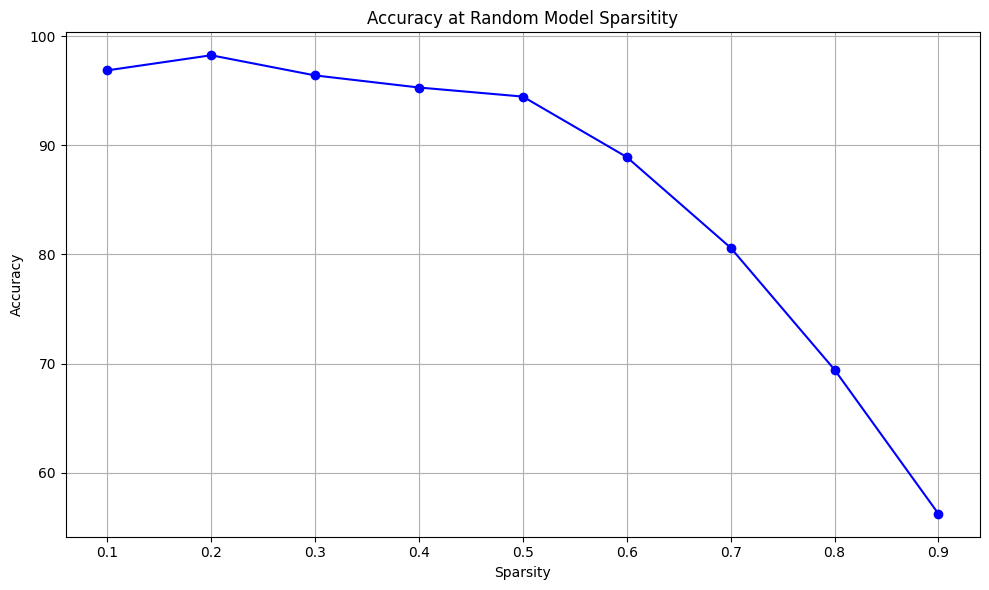

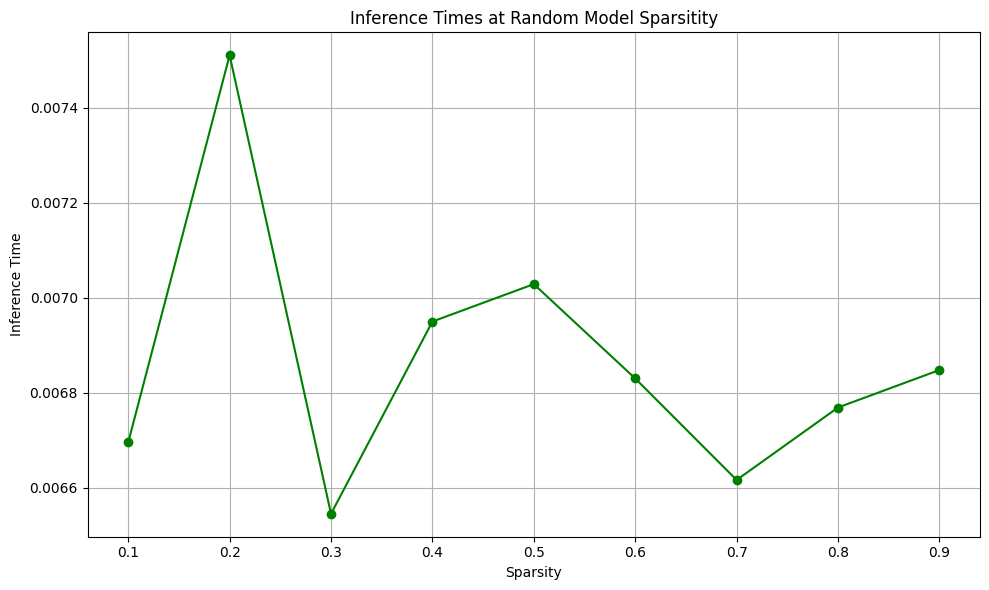

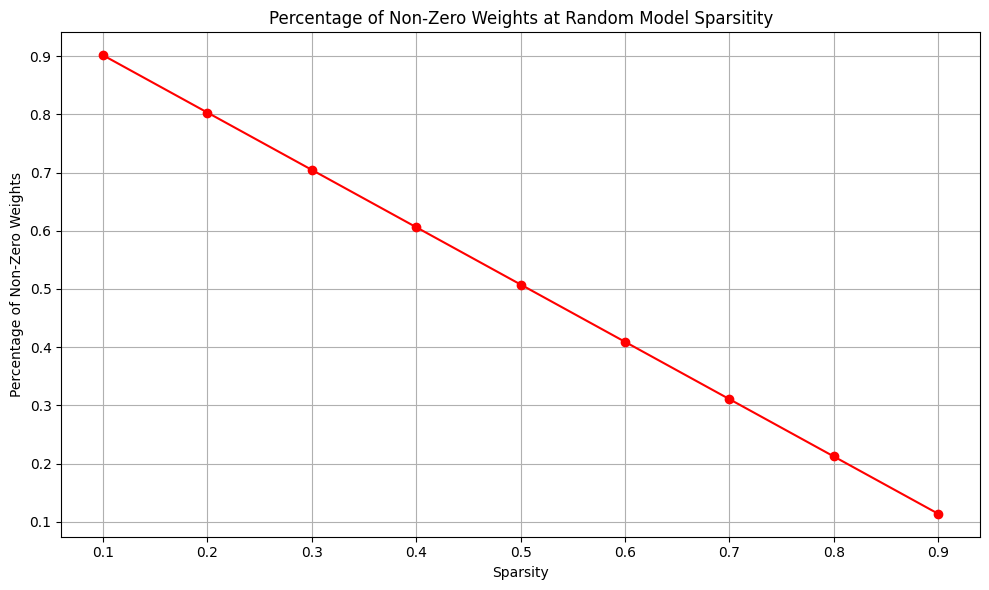

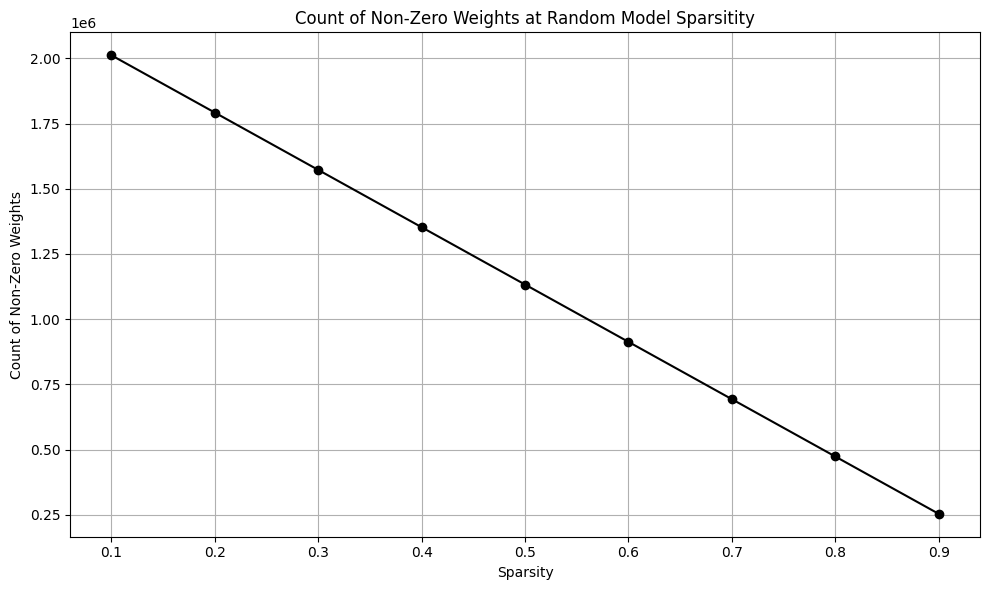

In [ ]:
#Accuracy
#Line chart
plt.figure(figsize=(10, 6))
plt.plot(sparsities, model_accs, marker='o', linestyle='-', color='b')
plt.xlabel('Sparsity')
plt.ylabel('Accuracy')
plt.title('Accuracy at Random Model Sparsitity')
plt.grid(True)

plt.tight_layout()
plt.show()

#Model Inference Times
#Line chart
plt.figure(figsize=(10, 6))
plt.plot(sparsities, model_times, marker='o', linestyle='-', color='g')
plt.xlabel('Sparsity')
plt.ylabel('Inference Time')
plt.title('Inference Times at Random Model Sparsitity')
plt.grid(True)

plt.tight_layout()
plt.show()

#Fraction of Non-Zero Weights
#Line chart
plt.figure(figsize=(10, 6))
plt.plot(sparsities, model_percentage_nonzero_weights, marker='o', linestyle='-', color='r')
plt.xlabel('Sparsity')
plt.ylabel('Percentage of Non-Zero Weights')
plt.title('Percentage of Non-Zero Weights at Random Model Sparsitity')
plt.grid(True)

plt.tight_layout()
plt.show()

#Parameter counts
#Line chart
plt.figure(figsize=(10, 6))
plt.plot(sparsities, model_nonzero_params, marker='o', linestyle='-', color='black')
plt.xlabel('Sparsity')
plt.ylabel('Count of Non-Zero Weights')
plt.title('Count of Non-Zero Weights at Random Model Sparsitity')
plt.grid(True)

plt.tight_layout()
plt.show()

### Threshold Pruning

In [18]:
#Pruning Sparsity Levels
thresholds = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09]

thres_model_accs = []
thres_model_sizes = []
thres_model_times = []
thres_model_params = []
thres_model_params = []
thres_model_nonzero_params = []
thres_model_percentage_nonzero_weights = []
x = 0

#Loops through the thresholds and saves the metrics
for i in thresholds:
  model = torch.load(f'/content/drive/My Drive/ENDG511GroupProject/Models/pruned_threshold_{i}_model.pth', weights_only=False)
   #Save the metrics
  thres_model_accs.append(evaluate_accuracy(model, val_loader))
  thres_model_sizes.append(os.path.getsize(f'/content/drive/My Drive/ENDG511GroupProject/Models/pruned_threshold_{i}_model.pth') / (1024 * 1024))
  thres_model_times.append(evaluate_model_time(model))
  thres_model_params.append(count_parameters(model))
  thres_model_params.append(count_parameters(model))
  thres_model_nonzero_params.append(count_nonzero_weights(model))
  x += 1

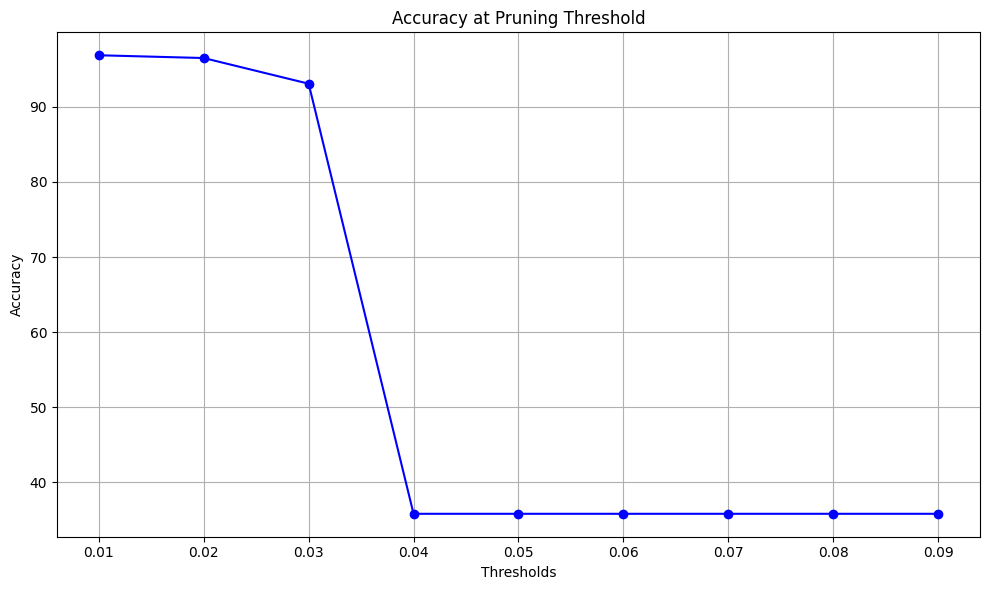

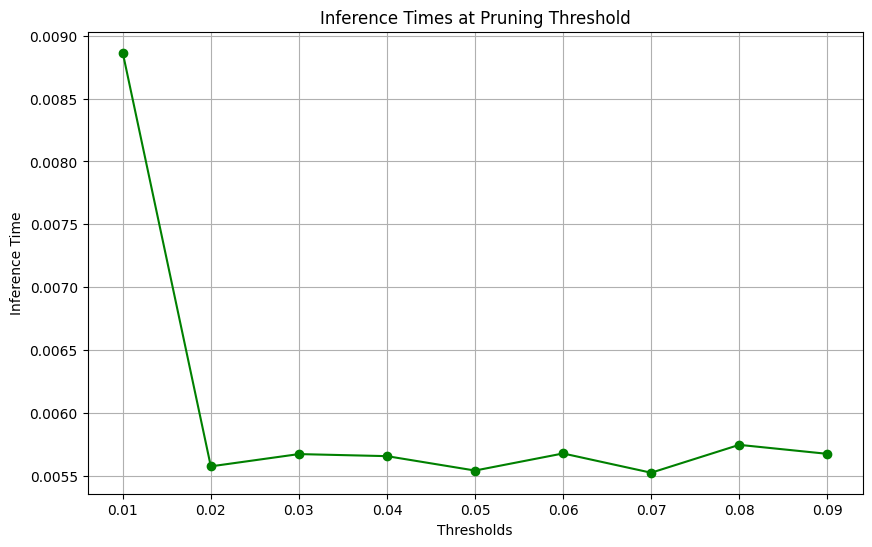

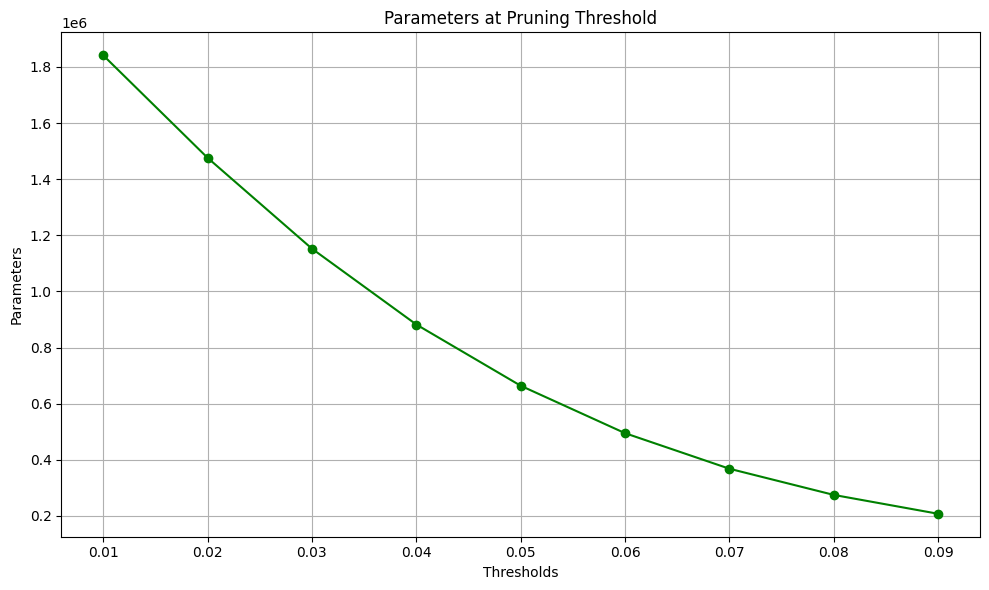

In [19]:
#Accuracy
#Line chart
plt.figure(figsize=(10, 6))
plt.plot(thresholds, thres_model_accs, marker='o', linestyle='-', color='b')
plt.xlabel('Thresholds')
plt.ylabel('Accuracy')
plt.title('Accuracy at Pruning Threshold')
plt.grid(True)

plt.tight_layout()
plt.show()

#Model Inference Times
#Line chart
plt.figure(figsize=(10, 6))
plt.plot(thresholds, thres_model_times, marker='o', linestyle='-', color='g')
plt.xlabel('Thresholds')
plt.ylabel('Inference Time')
plt.title('Inference Times at Pruning Threshold')
plt.grid(True)

#Model Param Counts
#Line chart
plt.figure(figsize=(10, 6))
plt.plot(thresholds, thres_model_nonzero_params, marker='o', linestyle='-', color='g')
plt.xlabel('Thresholds')
plt.ylabel('Parameters')
plt.title('Parameters at Pruning Threshold')
plt.grid(True)


plt.tight_layout()
plt.show()

### Structured pruning

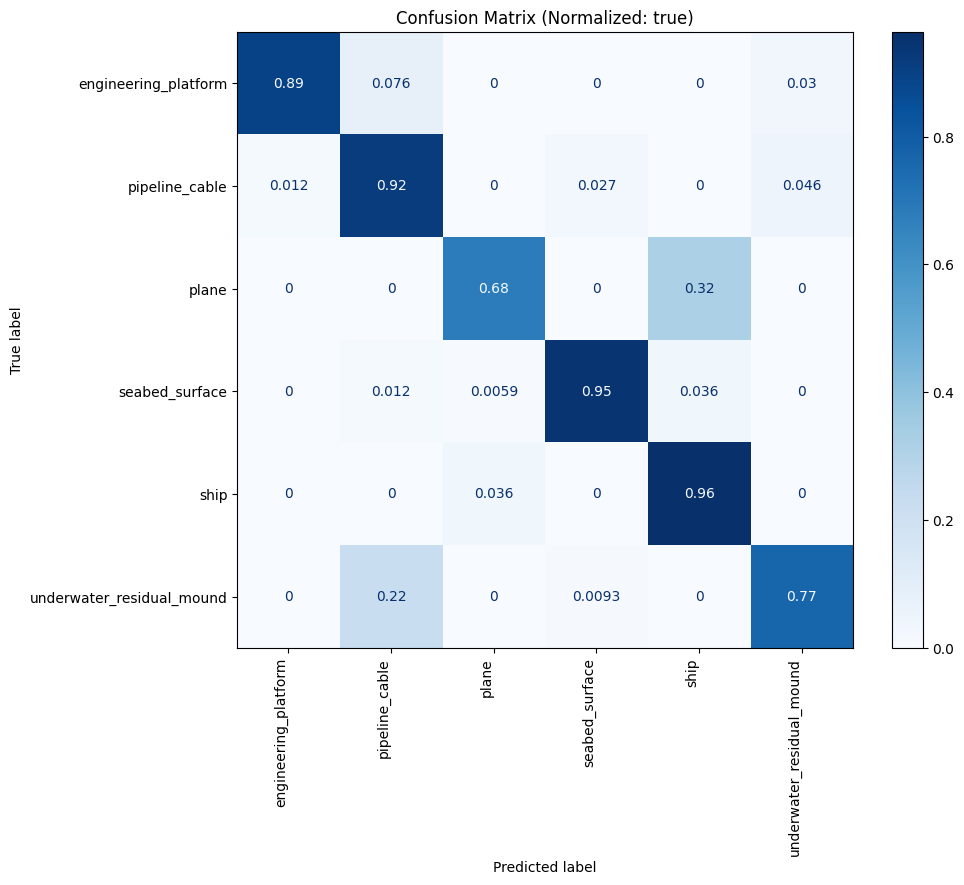

In [ ]:
#Confusion Matrix (Assisted by Chat GPT in creating this)

#Confusion matrix function
def get_confusion_matrix(model, dataloader, device, class_names=None, normalize=None, figsize=(10, 8)):
    model.eval()

    #Test the model and track the results
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    #Create a confusion maxtrix
    cm = confusion_matrix(all_labels, all_preds, normalize=normalize)

    fig, ax = plt.subplots(figsize=figsize)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, ax=ax)

    plt.setp(ax.get_xticklabels(), rotation=90, ha='right')

    title = "Confusion Matrix"
    if normalize:
        title += f" (Normalized: {normalize})"
    plt.title(title)

    return cm, fig

#Uncomment the one that should be shown
model = torch.load('/content/drive/My Drive/ENDG511GroupProject/Models/structured_pruned_model.pth', weights_only=False)
cm, fig = get_confusion_matrix(model=model, dataloader=val_loader ,device =device, class_names=dataset.classes, normalize ='true')
#cm, fig = get_confusion_matrix(model=model, dataloader=val_loader ,device =device, class_names=dataset.classes)

# Quantization

This was run on a seperate run time not expecting the imports from above

In [6]:
from google.colab import drive
# CONNECT TO GOOGLE DRIVE #
drive.mount('/content/drive')

Mounted at /content/drive


We will quantize in TF, so first we need to convert the formats using onnx as an intermediate

In [14]:
#Install necessary libraries (onnx needs different versions, running tf install afterwards seems to understand this and install the correct version)
!pip install onnx onnx2tf tensorflow

#Import required libraries
import onnx
import onnx2tf
import tensorflow as tf
import torch.onnx

#Load the model (on a CPU runtime)
pytorch_model = torch.load('/content/drive/My Drive/ENDG511GroupProject/Models/structured_pruned_model.pth',map_location=torch.device('cpu'), weights_only=False)

#Random fake input to trace the model (same size as expected)
input = torch.randn(1, 3, 224, 224)

#Export the model to ONNX format
onnx_file_path = "/content/drive/My Drive/ENDG511GroupProject/Models/export_model.onnx"
torch.onnx.export(pytorch_model, input, onnx_file_path, opset_version=11)


#Load the ONNX model
onnx_model_path = '/content/drive/My Drive/ENDG511GroupProject/Models/export_model.onnx'

#Convert the ONNX model to TensorFlow
tf_model = onnx2tf.convert(onnx_model_path)

#Save the converted TensorFlow model
tf_model_path = '/content/drive/My Drive/ENDG511GroupProject/Models/tf_model'
tf_model.save(tf_model_path)

  Using cached tensorflow-2.19.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
Using cached tensorflow-2.19.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (644.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.11.0 requires tensorflow==2.18.0, but you have tensorflow 2.19.0 which is incompatible.
tensorflow-text 2.18.1 requires tensorflow<2.19,>=2.18.0, but you have tensorflow 2.19.0 which is incompatible.
tf-keras 2.18.0 requires tensorflow<2.19,>=2.18, but you have tensorflow 2.19.0 which is incompatible.

Model optimizing started ============================================================
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/onnx2tf/onnx2tf.py", line 652, in convert
    result = subprocess.check_output(
             ^^^^^^^^^^^^^^^^^^

The model is now be loaded and quantized

In [8]:
import tensorflow as tf
import numpy as np
import os
import time
from sklearn.metrics import accuracy_score

In [24]:
saved_model_dir = '/content/drive/My Drive/ENDG511GroupProject/Models/tf_model'

#Create the converted
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
#Optimize into in8 (default)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

#Quantize the model and save it
quantized_model = converter.convert()
with open('/content/drive/My Drive/ENDG511GroupProject/Models/quantized_model.tflite', 'wb') as f:
  f.write(quantized_model)

Finally, we can assess the effects of the int8 quantization on model size

In [23]:
quant_size = (os.path.getsize('/content/drive/My Drive/ENDG511GroupProject/Models/quantized_model.tflite') / (1024 * 1024))
print(f"Quantized model size: {quant_size} MB")
base_size = (os.path.getsize('/content/drive/My Drive/ENDG511GroupProject/Models/structured_pruned_model.pth') / (1024 * 1024))
print(f"Base model size: {base_size} MB")
print(f"Quantized model is {(quant_size / base_size) * 100}% of the original size")

Quantized model size: 2.3860931396484375 MB
Base model size: 8.783964157104492 MB
Quantized model is 27.16419485521875% of the original size


In [4]:
#Main Dataset Path
main_path = '/content/drive/My Drive/ENDG511GroupProject/'
unprocessed_path = main_path + 'Datasets/complete_dataset_unprocessed/'
processed_path = main_path + 'Datasets/complete_dataset_processed/'
image_classes = ['plane', 'ship', 'engineering_platform', 'pipeline_cable', 'seabed_surface', 'underwater_residual_mound']

In [9]:
#Load dataset for the quantized testing
test_ds = tf.keras.utils.image_dataset_from_directory(
    processed_path,
    labels='inferred',
    label_mode='int',
    image_size=(224,224),
    batch_size=1,
    shuffle=False
)
class_names = test_ds.class_names

#Load the quantized model
interpreter = tf.lite.Interpreter(model_path='/content/drive/My Drive/ENDG511GroupProject/Models/quantized_model.tflite')
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Track times
inference_times = []

# Prediction loop
true = []
guesses = []

for images, labels in test_ds:
    img = tf.cast(images, tf.float32) / 255.0  # normalize if needed

    # Start timer
    start_time = time.time()

    # Run inference
    interpreter.set_tensor(input_details[0]['index'], img.numpy())
    interpreter.invoke()

    # End timer
    end_time = time.time()

    # Calculate and store inference time
    inference_time_ms = (end_time - start_time)
    inference_times.append(inference_time_ms)

    # Get prediction
    output = interpreter.get_tensor(output_details[0]['index'])
    pred = np.argmax(output, axis=1)

    true.append(int(labels.numpy()[0]))
    guesses.append(int(pred[0]))

# Accuracy
accuracy = accuracy_score(true, guesses)
print(f"Quantized Accuracy: {accuracy * 100:.2f}%")

# Inference time stats
avg_time = np.mean(inference_times)
print(f"Average inference time: {avg_time * 1000:.2f} ms per image")

Found 5412 files belonging to 6 classes.
Quantized Accuracy: 54.03%
Average inference time: 14.34 ms per image
